In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCurve = np.genfromtxt('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/HEPData-ins1894408-v2-csv/2Dexclusioncontour,fermionportal,Observed.csv',
                        skip_header=9,names=True,delimiter=',')

In [3]:
print(cmsCurve.dtype.names)

('m_Phi_GeV', 'm_chi_GeV')


In [4]:
# inputFiles = ['../../CMS-EXO-20-004/scanResults_S3D_uR_CMS_BPs_nocut.pcl']
inputFiles = ['/home/ramos/runScan_combined.pcl']
dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

In [5]:
models = []
mCols = ['$m_{med}$','$m_{DM}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0]}



In [7]:
# Remove duplicated data from other datasets
recastData = recastData[recastData['Data-takingperiod'] == 2017]

In [8]:
recastData = recastData[~np.isnan(recastData['$\mu^{UL}_{obs}$'])]

In [9]:
recastData

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,65619.060278,7419.322620,7419.322620,53253.136188,...,0.161302,0.137351,0.129712,0.129151,0.126578,0.126578,0.126578,0.126578,0.017126,0.010203
4,tchannel,DM+QCDjets,100.0,75.0,2017,41.5,32315.938274,7691.619773,7691.619773,26590.582198,...,0.150050,0.126804,0.125941,0.123195,0.117384,0.117384,0.117384,0.117384,0.043348,0.024185
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,27486.091363,839.026230,839.026230,18101.561725,...,0.239165,0.215753,0.203188,0.202125,0.200323,0.200323,0.200323,0.200323,0.054039,0.031882
10,tchannel,DM+QCDjets,300.0,200.0,2017,41.5,6399.035979,252.956715,252.956715,4424.765126,...,0.228847,0.198920,0.193613,0.193130,0.189686,0.189686,0.189686,0.189686,0.124985,0.059447
13,tchannel,DM+QCDjets,500.0,1.0,2017,41.5,8786.650015,222.610759,222.610759,6470.694272,...,0.463769,0.415981,0.387321,0.385587,0.382923,0.382923,0.382923,0.382923,0.113901,0.077426
16,tchannel,DM+QCDjets,500.0,200.0,2017,41.5,5196.117446,127.367600,127.367600,4001.642409,...,0.440483,0.393994,0.385868,0.385110,0.382537,0.382537,0.382537,0.382537,0.203579,0.127667
19,tchannel,DM+QCDjets,500.0,400.0,2017,41.5,777.108914,24.711769,24.711769,577.228299,...,0.331926,0.286205,0.279679,0.278919,0.271592,0.271592,0.271592,0.271592,0.734538,0.426565
22,tchannel,DM+QCDjets,750.0,1.0,2017,41.5,1135.482652,35.412580,35.412580,1253.323274,...,0.712679,0.642467,0.587248,0.584891,0.582108,0.582108,0.582108,0.582108,0.188009,0.131660
25,tchannel,DM+QCDjets,750.0,200.0,2017,41.5,938.692543,26.837485,26.837485,935.220177,...,0.701701,0.628430,0.612099,0.610481,0.607907,0.607907,0.607907,0.607907,0.258200,0.159888
28,tchannel,DM+QCDjets,750.0,400.0,2017,41.5,616.719469,15.834618,15.834618,539.920347,...,0.614968,0.547716,0.535570,0.534933,0.533432,0.533432,0.533432,0.533432,0.645767,0.404461


In [10]:
kfactor = 1.
lmuData = np.log10(recastData['$\mu^{UL}_{obs}$']/kfactor)

/tmp/ipykernel_107467/3270980453.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c=lmuData,cmap=plt.cm.get_cmap('Reds_r', 6),s=60)


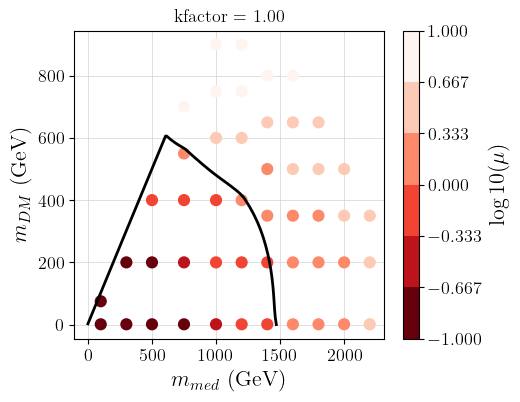

In [11]:
plt.scatter(x=recastData['$m_{med}$'],y=recastData['$m_{DM}$'],vmin=-1.0,vmax=1.0,
            c=lmuData,cmap=plt.cm.get_cmap('Reds_r', 6),s=60)
cbar = plt.colorbar(label=r'$\log10(\mu)$')
cbar.set_ticks([-1.0,-0.6666,-0.3333,0.0,0.33333,0.66666,1.0])
plt.plot(cmsCurve['m_Phi_GeV'],cmsCurve['m_chi_GeV'],label='CMS',linewidth=2,color='black')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.ylabel(r'$m_{DM}$ (GeV)')
# plt.ylim(-10,1400)
# plt.xlim(0,3100)
plt.title('kfactor = %1.2f' %kfactor)
plt.text(0.04,0.75,textstr,fontsize=16,bbox=dict(facecolor='none', edgecolor='black'),
         transform = plt.gca().transAxes)
plt.show()

In [12]:
pts = np.array([x for x in product(np.linspace(0.,2000.,300),np.linspace(0.,1000.,300))])
lmuPts = griddata(list(zip(recastData['$m_{med}$'],recastData['$m_{DM}$'])),
                  lmuData,pts)
pts = pts[~np.isnan(lmuPts)]
lmuPts = lmuPts[~np.isnan(lmuPts)]

/tmp/ipykernel_107467/376926223.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c=lmuPts,cmap=plt.cm.get_cmap('Reds_r', 6))


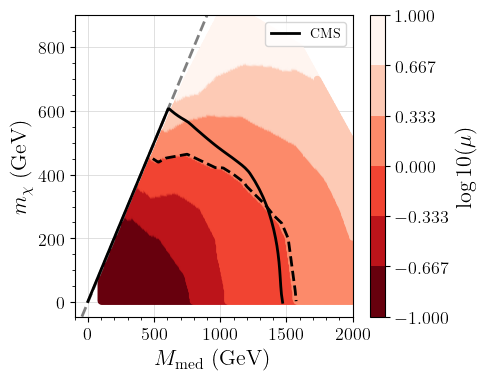

In [17]:
fig,ax = plt.subplots()

p = ax.scatter(x=pts[:,0],y=pts[:,1],vmin=-1.0,vmax=1.0,
            c=lmuPts,cmap=plt.cm.get_cmap('Reds_r', 6))
cbar = plt.colorbar(p,label=r'$\log10(\mu)$',ax=ax)
cbar.set_ticks([-1.0,-0.6666,-0.3333,0.0,0.33333,0.66666,1.0])
cs = ax.tricontour(pts[:,0],pts[:,1],lmuPts,levels=[0.0],
               linewidths=2,linestyles='--',colors='black')
# cs.collections[0].set_label('kfactor = %1.2f' %kfactor)

ax.axline((1, 1), slope=1, linestyle='--', color='gray')

ax.plot(cmsCurve['m_Phi_GeV'],cmsCurve['m_chi_GeV'],label='CMS',linewidth=2,color='black')
ax.legend(loc='upper right')
ax.set_xlabel(r'$M_{\rm med}$ (GeV)')
ax.set_ylabel(r'$m_{\chi}$ (GeV)')
# ax.set_ylim(10,1400)
# ax.set_xlim(10,3000)
ax.minorticks_on()
ax.text(0.05,0.75,textstr,fontsize=14,bbox=dict(facecolor='white'),
         transform = ax.transAxes)
# ax[0].set_title('kfactor = %1.2f' %kfactor)

plt.tight_layout()
plt.savefig('validation_plot_CMS.png')


plt.show()

In [31]:
pd.read_pickle('/home/camila/MG5/DMSimpt_S3D_uR_1j2j/Events/run_01/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,110.235906,129.674547,144.849228
bin_250.0_280.0_ErrorPlus,2.62914,2.855674,3.013771
bin_250.0_280.0_ErrorMinus,2.62914,2.855674,3.013771
bin_280.0_310.0,91.988666,104.404314,118.199479
bin_280.0_310.0_ErrorPlus,2.404975,2.560189,2.726779
bin_280.0_310.0_ErrorMinus,2.404975,2.560189,2.726779
bin_310.0_340.0,73.866836,87.097653,97.882963
bin_310.0_340.0_ErrorPlus,2.153998,2.336982,2.477454


In [14]:
recastData[recastData['$m_{DM}$']==550].T

,31
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,750.0
$m_{DM}$,550.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,319.157228
bin_250.0_280.0_ErrorPlus,8.091402
bin_250.0_280.0_ErrorMinus,8.091402
bin_280.0_310.0,256.76972


In [38]:
pd.read_pickle('../../../MG5/DMsimp_t-S3D_uR_PhiPhiToJJChiChi/Events/run_04/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,291.074612,341.403374,381.829749
bin_250.0_280.0_ErrorPlus,9.317909,10.099758,10.618742
bin_250.0_280.0_ErrorMinus,9.317909,10.099758,10.618742
bin_280.0_310.0,204.876323,250.124936,301.095635
bin_280.0_310.0_ErrorPlus,7.62677,8.480365,9.287392
bin_280.0_310.0_ErrorMinus,7.62677,8.480365,9.287392
bin_310.0_340.0,179.584008,218.164643,222.071385
bin_310.0_340.0_ErrorPlus,7.132102,7.916912,8.034273


In [24]:
recastData[recastData['$m_{DM}$']==550].T

,31
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,750.0
$m_{DM}$,550.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,319.157228
bin_250.0_280.0_ErrorPlus,8.091402
bin_250.0_280.0_ErrorMinus,8.091402
bin_280.0_310.0,256.76972
